# SIT307 8.1D – Machine Learning Mini Project
## Sydney Housing Price Prediction and Decision Support System

This project investigates whether property characteristics can be used to
predict residential sale prices across three different Sydney housing markets:
Blacktown, Parramatta, and Mosman.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sydney_housing_final_verified_105.csv")

df.head()

,suburb,address,sale_price,bedrooms,bathrooms,parking,property_type,listed_area_m2,sale_date,source_url,source_name,property_type_ml
0,Blacktown,25/8-10 Fourth Avenue,415000,2,1,1.0,Unit,109.0,16-09-2026,https://www.realestate.com.au/sold/in-blacktow...,realestate.com.au,Apartment
1,Blacktown,7 Highlands Crescent,1135000,3,2,4.0,House,765.0,15-09-2026,https://www.realestate.com.au/sold/in-blacktow...,realestate.com.au,House
2,Blacktown,81 Reservoir Road,1105000,4,2,2.0,House,NaN,15-09-2026,https://www.realestate.com.au/sold/in-blacktow...,realestate.com.au,House
3,Blacktown,17 St Pauls Way,828000,3,2,1.0,Townhouse,NaN,15-09-2026,https://www.realestate.com.au/sold/in-blacktow...,realestate.com.au,Townhouse
4,Blacktown,4 & 4A Joseph Street,1340000,5,2,1.0,House,713.0,14-09-2026,https://www.realestate.com.au/sold/in-blacktow...,realestate.com.au,House


In [3]:
print("Number of properties:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of properties: 105
Number of columns: 12


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   suburb            105 non-null    object 
 1   address           105 non-null    object 
 2   sale_price        105 non-null    int64  
 3   bedrooms          105 non-null    int64  
 4   bathrooms         105 non-null    int64  
 5   parking           90 non-null     float64
 6   property_type     105 non-null    object 
 7   listed_area_m2    42 non-null     float64
 8   sale_date         105 non-null    object 
 9   source_url        105 non-null    object 
 10  source_name       105 non-null    object 
 11  property_type_ml  105 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 10.0+ KB


In [5]:
df["suburb"].value_counts()

Blacktown     35
Parramatta    35
Mosman        35
Name: suburb, dtype: int64

In [6]:
df.isnull().sum()

suburb               0
address              0
sale_price           0
bedrooms             0
bathrooms            0
parking             15
property_type        0
listed_area_m2      63
sale_date            0
source_url           0
source_name          0
property_type_ml     0
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate properties:",
    df.duplicated(subset=["suburb", "address"]).sum()
)

Duplicate rows: 0
Duplicate properties: 0


In [8]:
df[
    ["sale_price", "bedrooms", "bathrooms", "parking", "listed_area_m2"]
].describe()

,sale_price,bedrooms,bathrooms,parking,listed_area_m2
count,1.050000e+02,105.000000,105.000000,90.000000,42.000000
mean,1.028124e+06,2.190476,1.504762,1.400000,272.561190
std,1.025495e+06,1.075024,0.652271,1.057876,278.737569
min,2.000000e+05,1.000000,1.000000,1.000000,40.000000
25%,5.600000e+05,2.000000,1.000000,1.000000,98.750000
50%,7.200000e+05,2.000000,1.000000,1.000000,122.500000
75%,1.105000e+06,2.000000,2.000000,1.000000,511.750000
max,8.700000e+06,7.000000,4.000000,6.000000,1182.400000


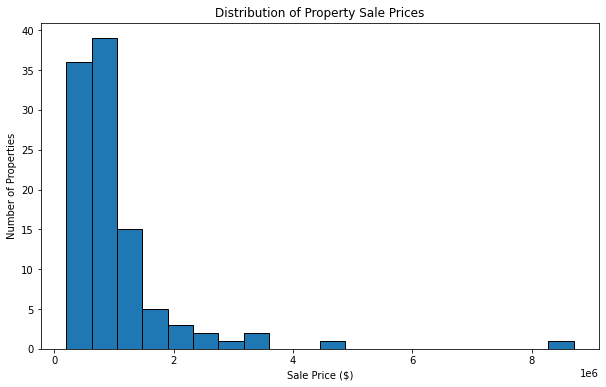

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(df["sale_price"], bins=20, edgecolor="black")

plt.title("Distribution of Property Sale Prices")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Properties")

plt.show()

In [10]:
suburb_price_summary = df.groupby("suburb")["sale_price"].agg(
    ["count", "mean", "median", "min", "max"]
)

suburb_price_summary

,count,mean,median,min,max
suburb,,,,,
Blacktown,35,8.422143e+05,732500.0,375000,1900000
Mosman,35,1.661557e+06,1030000.0,700000,8700000
Parramatta,35,5.806000e+05,580000.0,200000,800000


<Figure size 720x432 with 0 Axes>

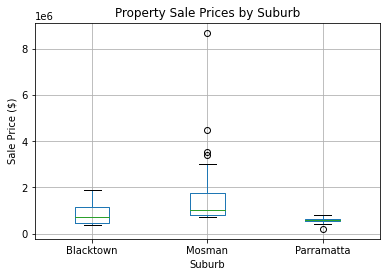

In [11]:
plt.figure(figsize=(10, 6))

df.boxplot(column="sale_price", by="suburb")

plt.title("Property Sale Prices by Suburb")
plt.suptitle("")
plt.xlabel("Suburb")
plt.ylabel("Sale Price ($)")

plt.show()

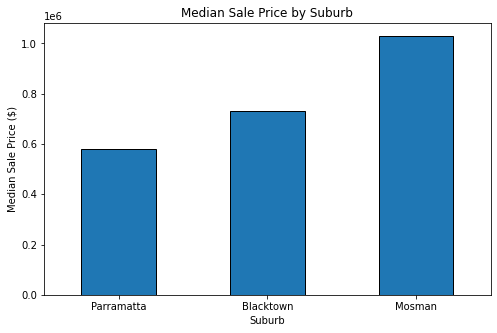

In [12]:
median_prices = df.groupby("suburb")["sale_price"].median().sort_values()

median_prices.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Median Sale Price by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Median Sale Price ($)")
plt.xticks(rotation=0)

plt.show()

In [13]:
property_counts = pd.crosstab(
    df["suburb"],
    df["property_type_ml"]
)

property_counts

property_type_ml,Apartment,House,Studio,Townhouse
suburb,,,,
Blacktown,15,14,0,6
Mosman,31,3,0,1
Parramatta,33,0,1,1


In [14]:
type_price_summary = df.groupby("property_type_ml")["sale_price"].agg(
    ["count", "mean", "median", "min", "max"]
)

type_price_summary

,count,mean,median,min,max
property_type_ml,,,,,
Apartment,79,8.400316e+05,650000.0,375000,4500000
House,17,1.987353e+06,1300000.0,1007500,8700000
Studio,1,2.000000e+05,200000.0,200000,200000
Townhouse,8,9.506875e+05,761250.0,650000,2380000


<Figure size 720x432 with 0 Axes>

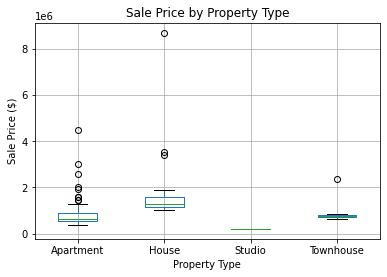

In [15]:
plt.figure(figsize=(10, 6))

df.boxplot(column="sale_price", by="property_type_ml")

plt.title("Sale Price by Property Type")
plt.suptitle("")
plt.xlabel("Property Type")
plt.ylabel("Sale Price ($)")

plt.show()

In [16]:
df["sale_date"] = pd.to_datetime(
    df["sale_date"],
    format="%d-%m-%Y"
)

print("Earliest sale:", df["sale_date"].min())
print("Latest sale:", df["sale_date"].max())

Earliest sale: 2026-05-13 00:00:00
Latest sale: 2026-09-17 00:00:00


In [17]:
df["sale_month"] = df["sale_date"].dt.to_period("M")

monthly_prices = df.groupby("sale_month")["sale_price"].median()

monthly_prices

sale_month
2026-05    1030000.0
2026-06    1570000.0
2026-07    1007500.0
2026-08     650000.0
2026-09     650000.0
Freq: M, Name: sale_price, dtype: float64

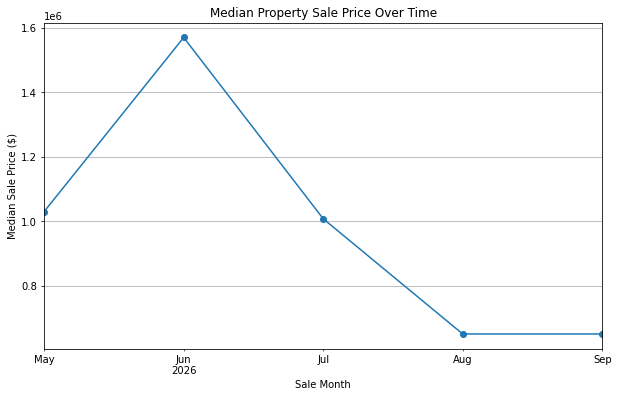

In [18]:
monthly_prices.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Median Property Sale Price Over Time")
plt.xlabel("Sale Month")
plt.ylabel("Median Sale Price ($)")
plt.grid(True)

plt.show()

In [19]:
monthly_suburb = (
    df.groupby(["sale_month", "suburb"])["sale_price"]
      .median()
      .unstack()
)

monthly_suburb

suburb,Blacktown,Mosman,Parramatta
sale_month,,,
2026-05,NaN,1030000.0,NaN
2026-06,NaN,1570000.0,NaN
2026-07,NaN,1007500.0,NaN
2026-08,797500.0,975000.0,590000.0
2026-09,700000.0,827500.0,577500.0


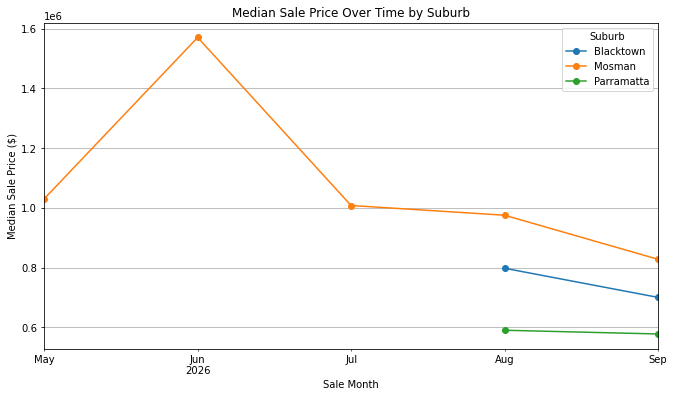

In [20]:
monthly_suburb.plot(
    marker="o",
    figsize=(11, 6)
)

plt.title("Median Sale Price Over Time by Suburb")
plt.xlabel("Sale Month")
plt.ylabel("Median Sale Price ($)")
plt.grid(True)
plt.legend(title="Suburb")

plt.show()

In [21]:
features = [
    "suburb",
    "bedrooms",
    "bathrooms",
    "parking",
    "property_type_ml"
]

X = df[features]
y = df["sale_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (105, 5)
y shape: (105,)


,suburb,bedrooms,bathrooms,parking,property_type_ml
0,Blacktown,2,1,1.0,Apartment
1,Blacktown,3,2,4.0,House
2,Blacktown,4,2,2.0,House
3,Blacktown,3,2,1.0,Townhouse
4,Blacktown,5,2,1.0,House


## Initial Feature Hypothesis

Before model development, I expect the following three variables to have the
strongest influence on property sale price:

1. **Suburb** – The exploratory analysis shows substantial differences in median
   sale prices between Parramatta, Blacktown and Mosman, suggesting that location
   is likely to be an important predictor.

2. **Property type** – Houses have a substantially higher median sale price than
   apartments in this dataset, suggesting that dwelling type may influence price.

3. **Bedrooms** – The number of bedrooms provides an indication of property size
   and capacity and is available for every property in the dataset.

These are initial hypotheses rather than confirmed relationships. Their importance
will be reconsidered after model development and evaluation.

In [22]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Missing Percentage", ascending=False)

,Missing Values,Missing Percentage
listed_area_m2,63,60.000000
parking,15,14.285714


In [23]:
Q1 = df["sale_price"].quantile(0.25)
Q3 = df["sale_price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["sale_price"] < lower_bound) |
    (df["sale_price"] > upper_bound)
]

print("IQR upper bound: $", upper_bound)

outliers[
    ["suburb", "address", "sale_price",
     "bedrooms", "bathrooms", "property_type_ml"]
].sort_values("sale_price", ascending=False)

IQR upper bound: $ 1922500.0


,suburb,address,sale_price,bedrooms,bathrooms,property_type_ml
82,Mosman,5 Botanic Road,8700000,4,3,House
74,Mosman,G05/15-25 Myahgah Road,4500000,2,2,Apartment
94,Mosman,105 Holt Avenue,3550000,4,3,House
96,Mosman,96 Glover Street,3390000,4,3,House
101,Mosman,7/8 Earl Street,3000000,3,2,Apartment
77,Mosman,4/139-153 Middle Head Road,2600000,3,2,Apartment
92,Mosman,10/116 Belmont Road,2380000,3,2,Townhouse
100,Mosman,32B/2 Brady Street,2000000,2,2,Apartment
89,Mosman,31/2B Brady Street,1925000,3,2,Apartment


### Data Quality and Outlier Decisions

The dataset contains missing values in `parking` and `listed_area_m2`.
Approximately 60% of the area values are missing, so this variable is excluded
from the primary predictive models rather than extensively imputing artificial
values. Missing parking values will be handled using median imputation within
the modelling pipeline.

The IQR method also identifies several high-priced properties as potential
outliers. These observations are retained because they represent genuine
high-value properties, particularly within the Mosman market, rather than
obvious data-entry errors. Their effect on prediction errors will be examined
during model evaluation.

# Part 3 – Model Development and Evaluation

Three different regression approaches will be compared:

- **Linear Regression** provides a simple and interpretable baseline but may
  underfit nonlinear relationships.
- **Random Forest Regression** can model nonlinear relationships and interactions
  but may overfit a relatively small dataset.
- **Gradient Boosting Regression** sequentially corrects prediction errors and can
  capture complex patterns, although excessive complexity may also cause overfitting.

Before training, I expect the tree-based models to outperform Linear Regression
because property prices are unlikely to depend on the available characteristics
in a purely linear manner.

In [24]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [25]:
numeric_features = [
    "bedrooms",
    "bathrooms",
    "parking"
]

categorical_features = [
    "suburb",
    "property_type_ml"
]

In [26]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training properties:", len(X_train))
print("Testing properties:", len(X_test))

Training properties: 84
Testing properties: 21


In [28]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

In [29]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [30]:
models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = {}

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        return_train_score=True
    )

    cv_results[name] = scores

In [31]:
results = []

for name, scores in cv_results.items():

    results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean(),
        "Train R2": scores["train_R2"].mean()
    })

results_df = pd.DataFrame(results)

results_df.round(3)

,Model,CV MAE,CV RMSE,CV R2,Train R2
0,Linear Regression,441572.653,665593.603,0.106,0.619
1,Random Forest,282236.053,614214.352,0.396,0.850
2,Gradient Boosting,305556.177,697370.660,0.261,0.875


## Final Model Selection

Based on the five-fold cross-validation results, Random Forest Regression was
selected for further evaluation. It achieved the lowest mean cross-validation
MAE and RMSE and the highest mean cross-validation R² of the three approaches.

The Random Forest still shows evidence of overfitting because its training R²
is considerably higher than its cross-validation R². However, Gradient
Boosting displays an even larger train-validation performance gap and weaker
cross-validation results.

The results support the initial expectation that a nonlinear tree-based model
would perform better than the Linear Regression baseline on this dataset.

In [32]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['bedrooms', 'bathrooms',
                                                   'parking']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['suburb',
                                                   'property_type_ml'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [33]:
y_pred = random_forest_model.predict(X_test)

In [34]:
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print(f"Test MAE: ${test_mae:,.2f}")
print(f"Test RMSE: ${test_rmse:,.2f}")
print(f"Test R²: {test_r2:.3f}")

Test MAE: $337,690.94
Test RMSE: $705,183.35
Test R²: 0.441


In [35]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison["Absolute Error"] = abs(
    comparison["Actual Price"] -
    comparison["Predicted Price"]
)

comparison.head(10)

,Actual Price,Predicted Price,Absolute Error
30,600000,1.571946e+06,971946.166667
65,641000,6.127850e+05,28215.019503
64,800000,6.127850e+05,187215.019503
53,540000,6.127850e+05,72784.980497
45,705000,6.127850e+05,92215.019503
94,3550000,3.965427e+06,415426.745054
104,750000,8.960630e+05,146062.977119
47,425000,4.914200e+05,66419.954074
10,415000,4.503377e+05,35337.744658
0,415000,4.503377e+05,35337.744658


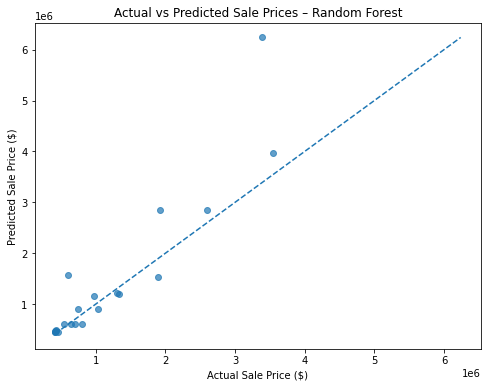

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted Sale Prices – Random Forest")
plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")

plt.show()

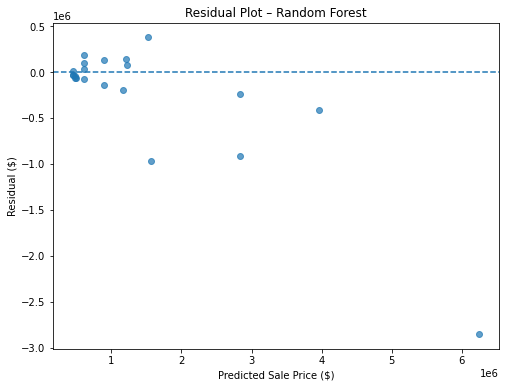

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot – Random Forest")
plt.xlabel("Predicted Sale Price ($)")
plt.ylabel("Residual ($)")

plt.show()

In [38]:
error_analysis = X_test.copy()

error_analysis["Actual Price"] = y_test
error_analysis["Predicted Price"] = y_pred

error_analysis["Error"] = (
    error_analysis["Actual Price"] -
    error_analysis["Predicted Price"]
)

error_analysis["Absolute Error"] = abs(
    error_analysis["Error"]
)

largest_errors = error_analysis.sort_values(
    "Absolute Error",
    ascending=False
).head(5)

largest_errors

,suburb,bedrooms,bathrooms,parking,property_type_ml,Actual Price,Predicted Price,Error,Absolute Error
96,Mosman,4,3,2.0,House,3390000,6.239908e+06,-2.849908e+06,2.849908e+06
30,Blacktown,3,2,2.0,Apartment,600000,1.571946e+06,-9.719462e+05,9.719462e+05
89,Mosman,3,2,2.0,Apartment,1925000,2.841874e+06,-9.168740e+05,9.168740e+05
94,Mosman,4,3,NaN,House,3550000,3.965427e+06,-4.154267e+05,4.154267e+05
31,Blacktown,7,4,6.0,House,1900000,1.524888e+06,3.751125e+05,3.751125e+05


In [39]:
largest_errors_with_address = largest_errors.merge(
    df[["address"]],
    left_index=True,
    right_index=True
)

largest_errors_with_address[
    [
        "address",
        "suburb",
        "bedrooms",
        "bathrooms",
        "parking",
        "property_type_ml",
        "Actual Price",
        "Predicted Price",
        "Absolute Error"
    ]
]

,address,suburb,bedrooms,bathrooms,parking,property_type_ml,Actual Price,Predicted Price,Absolute Error
96,96 Glover Street,Mosman,4,3,2.0,House,3390000,6.239908e+06,2.849908e+06
30,903/5 Second Avenue,Blacktown,3,2,2.0,Apartment,600000,1.571946e+06,9.719462e+05
89,31/2B Brady Street,Mosman,3,2,2.0,Apartment,1925000,2.841874e+06,9.168740e+05
94,105 Holt Avenue,Mosman,4,3,NaN,House,3550000,3.965427e+06,4.154267e+05
31,13 Lancaster Street,Blacktown,7,4,6.0,House,1900000,1.524888e+06,3.751125e+05


## Part 4 – Analysis of the Five Largest Prediction Errors

The five largest test-set errors show an important limitation of the model:
properties with the same suburb, bedroom count, bathroom count, parking and
property type can still have substantially different market values.

The largest error occurred for 96 Glover Street, Mosman. The Random Forest
predicted approximately 6.24 million dollars compared with its actual sale price of
3.39 million dollars. The property is a four-bedroom, three-bathroom house with two
parking spaces on approximately 379 m². The model does not include land size,
precise location or detailed property characteristics, and the relatively small
number of Mosman houses makes predictions for this category less stable.

903/5 Second Avenue, Blacktown was also substantially overpredicted. Although
it has three bedrooms, two bathrooms and two parking spaces, it is an apartment
that sold for 600,000 dollars. The large error suggests that the available predictors
do not sufficiently represent differences in property size and location within
each suburb.

31/2B Brady Street, Mosman was overpredicted by approximately 917,000 dollars. It is
a three-bedroom apartment in a specific residential development. Characteristics
such as floor area, building quality, precise location and development-specific
factors are absent from the model.

105 Holt Avenue, Mosman was overpredicted by approximately 415,000 dollars. Parking
information was unavailable in the collected dataset and therefore had to be
imputed during preprocessing. Other characteristics such as architectural style,
condition and precise location are also not represented.

13 Lancaster Street, Blacktown was underpredicted by approximately 375,000 dollars.
The listing describes a recently constructed seven-bedroom home on a large block
with premium and flexible living features. These characteristics are only
partially represented by the simple numerical predictors available to the model.

Overall, the error analysis suggests that future models could benefit from
reliable land or floor area, precise location, property age, renovation or
condition information, and additional indicators of property quality. A larger
dataset would also provide more examples of unusual and high-value properties.

In [40]:
error_analysis["Prediction Direction"] = np.where(
    error_analysis["Error"] > 0,
    "Underpredicted",
    "Overpredicted"
)

largest_errors = error_analysis.sort_values(
    "Absolute Error",
    ascending=False
).head(5)

largest_errors_with_address = largest_errors.merge(
    df[["address"]],
    left_index=True,
    right_index=True
)

largest_errors_with_address[
    [
        "address",
        "suburb",
        "Actual Price",
        "Predicted Price",
        "Absolute Error",
        "Prediction Direction"
    ]
]

,address,suburb,Actual Price,Predicted Price,Absolute Error,Prediction Direction
96,96 Glover Street,Mosman,3390000,6.239908e+06,2.849908e+06,Overpredicted
30,903/5 Second Avenue,Blacktown,600000,1.571946e+06,9.719462e+05,Overpredicted
89,31/2B Brady Street,Mosman,1925000,2.841874e+06,9.168740e+05,Overpredicted
94,105 Holt Avenue,Mosman,3550000,3.965427e+06,4.154267e+05,Overpredicted
31,13 Lancaster Street,Blacktown,1900000,1.524888e+06,3.751125e+05,Underpredicted


# Part 5 – Model Deployment

For the final stage of the project, I developed a simple web application using
Streamlit. The application allows a user to enter property characteristics and
receive an estimated sale price from the trained Random Forest model.

In [44]:
import joblib

joblib.dump(
    random_forest_model,
    "housing_price_model.pkl"
)

print("Final model trained on all data and saved successfully.")

Final model trained on all data and saved successfully.


In [42]:
app_code = '''
import streamlit as st
import pandas as pd
import joblib

# Load the trained model
model = joblib.load("housing_price_model.pkl")

st.title("Sydney Housing Price Predictor")

st.write("Enter the property details below to estimate its sale price.")

# Property inputs
suburb = st.selectbox(
    "Suburb",
    ["Blacktown", "Parramatta", "Mosman"]
)

property_type = st.selectbox(
    "Property Type",
    ["Apartment", "House", "Townhouse", "Studio"]
)

bedrooms = st.number_input(
    "Bedrooms",
    min_value=1,
    max_value=10,
    value=2
)

bathrooms = st.number_input(
    "Bathrooms",
    min_value=1,
    max_value=6,
    value=1
)

parking = st.number_input(
    "Parking Spaces",
    min_value=0,
    max_value=10,
    value=1
)

# Predict when button is clicked
if st.button("Predict Price"):

    input_data = pd.DataFrame({
        "suburb": [suburb],
        "bedrooms": [bedrooms],
        "bathrooms": [bathrooms],
        "parking": [parking],
        "property_type_ml": [property_type]
    })

    prediction = model.predict(input_data)[0]

    st.success(
        f"Estimated Sale Price: ${prediction:,.0f}"
    )
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py created successfully.")

app.py created successfully.


In [43]:
import os

print("Model file exists:", os.path.exists("housing_price_model.pkl"))
print("App file exists:", os.path.exists("app.py"))

Model file exists: True
App file exists: True


### Web Application

A simple web application was developed using Streamlit to make the trained
Random Forest model easier to use. The application allows the user to select
a suburb and property type and enter the number of bedrooms, bathrooms and
parking spaces.

When the user clicks the **Predict Price** button, the entered values are
converted into a pandas DataFrame with the same feature structure used during
model training. The saved machine learning pipeline then preprocesses the
inputs and generates an estimated sale price.

For example, a Blacktown apartment with 2 bedrooms, 1 bathroom and 1 parking
space produced an estimated sale price of approximately $437,312.

### Running the Application

The application requires `app.py` and `housing_price_model.pkl` to be stored
in the same folder.

Required packages can be installed using:

pip install streamlit pandas scikit-learn joblib

The application can then be started from the command line using:

streamlit run app.py

After starting the application, it can be opened in a web browser. The user
enters the property characteristics and clicks Predict Price to obtain the
estimated sale price.

### Reflection and Limitations

The Streamlit application provides a simple way to use the trained model without
requiring the user to run Python code manually. One challenge during deployment
was model compatibility between the Jupyter environment and the local Python
environment. The saved Random Forest model could not initially be loaded because
different versions of scikit-learn were being used. To solve this, the final
model was trained and saved again in the local environment used to run the
Streamlit application.


Important property information such as reliable land or floor area, property
condition, renovation quality, exact location, age, views and nearby amenities
is unavailable or incomplete which is one of the main limitations of this model. These factors may help explain some of the large prediction errors found earlier in the analysis.
